# WDBC Binary Classification Project
Using scikit-learn to classify breast cancer tumors as malignant or benign.

## Step 2: Load the Dataset

In [35]:
from sklearn import datasets, svm, tree, neighbors, ensemble, metrics
import matplotlib.pyplot as plt
import numpy as np

wdbc = datasets.load_breast_cancer()
X = wdbc.data
y = wdbc.target

print("Data shape:", X.shape)
print("Target shape:", y.shape)
print("Target names:", wdbc.target_names)
print("First 5 feature names:", wdbc.feature_names[:5])

Data shape: (569, 30)
Target shape: (569,)
Target names: ['malignant' 'benign']
First 5 feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']


## Step 3: Train the Default SVM Classifier
Calculate accuracy, precision, and recall.

In [36]:
model = svm.SVC()
model.fit(X, y)
predict = model.predict(X)

print("Default SVM Metrics:")
print("Accuracy:", round(metrics.accuracy_score(y, predict), 4))
print("Precision:", round(metrics.precision_score(y, predict), 4))
print("Recall:", round(metrics.recall_score(y, predict), 4))

Default SVM Metrics:
Accuracy: 0.9227
Precision: 0.9023
Recall: 0.9832


## Step 4: Compare Multiple Classifiers

In [37]:
models = {
    "SVM": svm.SVC(),
    "Decision Tree": tree.DecisionTreeClassifier(random_state=42),
    "KNN": neighbors.KNeighborsClassifier(),
    "Random Forest": ensemble.RandomForestClassifier(random_state=42)
}

results = {}
for name, clf in models.items():
    clf.fit(X, y)
    pred = clf.predict(X)
    acc = metrics.accuracy_score(y, pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

SVM Accuracy: 0.9227
Decision Tree Accuracy: 1.0000
KNN Accuracy: 0.9473
Random Forest Accuracy: 1.0000


## Step 5: Find the Best Classifier

In [38]:
best_name = max(results, key=results.get)
print(f"Best Classifier: {best_name} (Accuracy: {results[best_name]:.4f})")

Best Classifier: Decision Tree (Accuracy: 1.0000)


## Step 6: Confusion Matrix

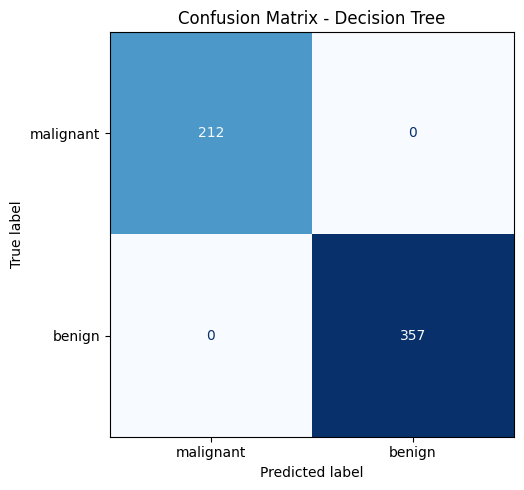

Saved: wdbc_classification_matrix.png


In [39]:
best_model = models[best_name]
best_pred = best_model.predict(X)
cm = metrics.confusion_matrix(y, best_pred)

disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wdbc.target_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.savefig("wdbc_classification_matrix.png", dpi=150)
plt.show()
print("Saved: wdbc_classification_matrix.png")

## Step 7: Scatter Plot

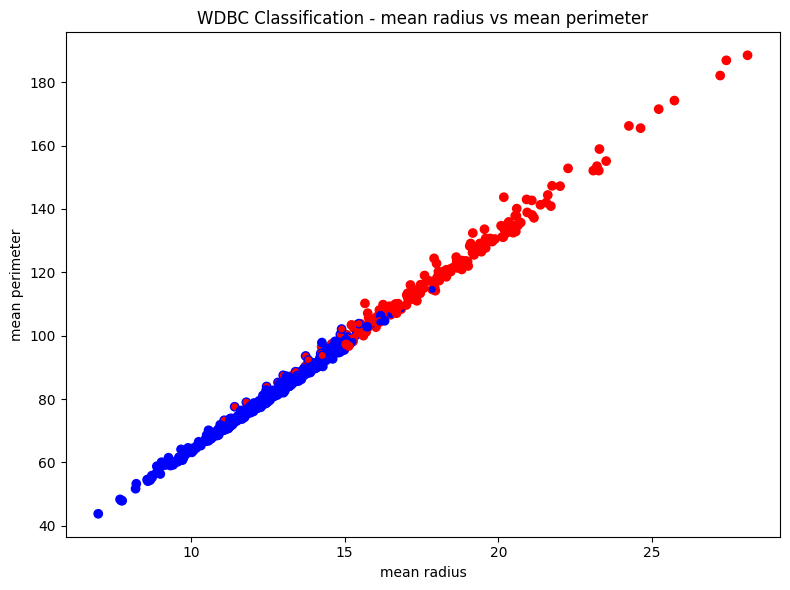

Saved: wdbc_classification_scatter.png


In [40]:
cmap = np.array([
    (1, 0, 0),   # Red for malignant
    (0, 0, 1)    # Blue for benign
])

x_feature = 0
y_feature = 2

plt.figure(figsize=(8, 6))

plt.title("WDBC Classification - " + wdbc.feature_names[x_feature] + " vs " + wdbc.feature_names[y_feature])

plt.scatter(
    X[:, x_feature],
    X[:, y_feature],
    c=cmap[y],
    edgecolors=cmap[predict]
)

plt.xlabel(wdbc.feature_names[x_feature])
plt.ylabel(wdbc.feature_names[y_feature])

plt.tight_layout()
plt.savefig("wdbc_classification_scatter.png", dpi=150)
plt.show()
print("Saved: wdbc_classification_scatter.png")